# Revenue-Optimal Dynamic Pricing using Reinforcement Learning
#### Policy Learning in a Competitive and Seasonal Synthetic Market

--- 

A company has recently launched a new product, but early performance has been disappointing. Sales volumes remain low, margins are unstable, and there is no historical data available on how customers respond to price changes. At the same time, the market is highly competitive, with competitors adjusting their prices frequently in response to observed behavior.

A new Pricing Manager is hired to address the situation. Given the lack of data, the problem cannot be solved immediately with advanced machine learning techniques. Instead, the manager proposes a structured, phased approach that allows the company to gradually learn about demand, competition, and optimal pricing strategies while maintaining business performance.

This problem is particularly well-suited for reinforcement learning. Pricing is inherently a sequential decision-making process: each price decision influences future demand, competitor reactions, and the information available for future decisions. Unlike static optimization or traditional supervised learning, reinforcement learning explicitly accounts for these dynamics, learning policies that balance short-term revenue with long-term gains through exploration. This is especially important in environments with strong feedback loops, delayed effects, and strategic interactions, as is the case in competitive pricing.

Dynamic pricing with reinforcement learning has broad applicability across industries where prices can be adjusted frequently and demand is uncertain or reactive. Examples include e-commerce and retail, airlines and hospitality, ride-hailing platforms, financial services, and digital marketplaces.

To address the challenge, the manager defines a roadmap where each phase is driven by data availability rather than development time. Each phase may take up to one quarter, depending on how quickly sufficient data is collected to support the next level of modeling. The development time of each phase is not acccounted for in the generated time series.

#### The project progresses through the following phases:

- Phase 0: data collection
- Phase 1: structural demand and elasticity validation
- Phase 2: myopic revenue optimization

### Phase 0: Data Collection

At the start of this project, the company faces a complete lack of historical data. The product was launched with a fixed price of 150, but no structured information is available on how demand responds to price changes or how competitors behave over time. This creates a cold-start problem where traditional modeling approaches are not yet feasible.

To address this, the objective of Phase 0 is to generate an initial dataset while maintaining reasonable business performance. Since real data is unavailable, the entire environment is simulated using a structural demand model that captures key market dynamics, including price elasticity, cross-price effects, seasonality, competitor reactions, and autoregressive demand shocks. This allows controlled experimentation while preserving realistic behavior.

A rule-based pricing policy is implemented based on domain intuition, allowing gradual price adjustments in response to observed signals such as recent demand and competitor price movements. During the first 40 days, prices remain fixed to establish a stable baseline and accumulate sufficient data to compute meaningful features. After this period, the rule-based logic begins adapting prices dynamically.

The market environment is highly competitive, with competitor prices reacting continuously to the agent’s pricing decisions, reinforcing the need for a dynamic and adaptive pricing strategy.

By the end of this phase, the system produces a consistent and sufficiently rich dataset, including prices, demand, competitor behavior, and revenue. This dataset serves as the foundation for all subsequent phases, where more advanced modeling and optimization techniques will be introduced.


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import exploration_policy, simulate, MarketPriors

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()


In [3]:
priors = MarketPriors()
df_first_qt = simulate(90, exploration_policy, priors)

print(df_first_qt.shape)
df_first_qt.tail()

(91, 7)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue
86,2025-03-28,121.440457,128.812906,8.406654e-06,-0.113406,14.904834,715.759816
87,2025-03-29,137.572785,130.031039,2.958194e-06,-0.176007,7.698805,397.217781
88,2025-03-30,135.538258,132.051480,9.956995e-07,-0.394795,6.949169,324.928128
89,2025-03-31,142.179888,138.322897,3.205737e-07,-0.337373,6.561266,339.204082
90,2025-04-01,133.522361,141.209000,8.713244e-01,-0.356152,16.178875,989.509104


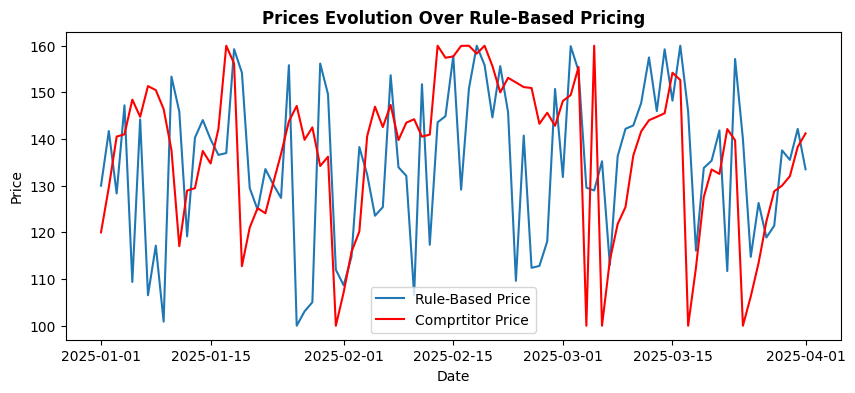

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["price_agent"], label="Rule-Based Price")
plt.plot(df_first_qt["date"], df_first_qt["price_competitor"], label="Comprtitor Price", color="red")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.title("Prices Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

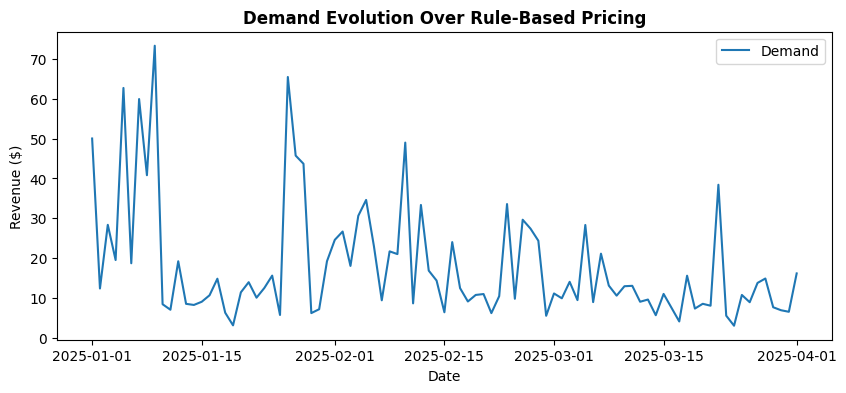

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["realized_demand"], label="Demand")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Demand Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

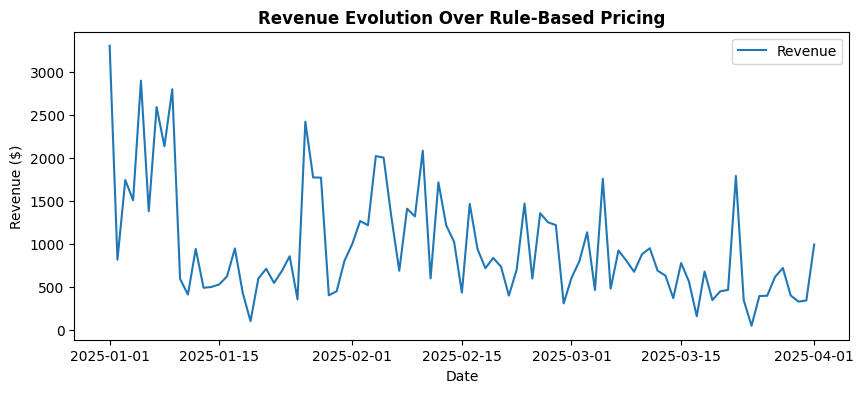

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["revenue"], label="Revenue")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Revenue Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

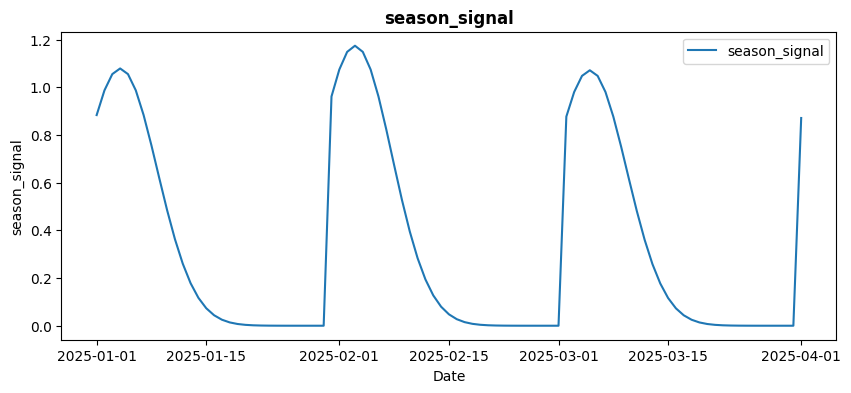

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_first_qt["date"], df_first_qt["season_signal"], label="season_signal")


plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("season_signal")
plt.title("season_signal", fontweight="bold")
plt.show()

In [8]:
df_first_qt.to_csv("data/phase_0.csv", index=False)

### Q1 Data Analysis

---

#### 1. Prices Behavior (Agent vs Competitor)

##### Observations
- The agent price (blue) is highly volatile, consistent with uniform random exploration.
- The competitor price (red) shows a clear downward trend over time with local fluctuations.
- The price gap evolves structurally:
  - Early period: frequent overlap between agent and competitor prices
  - Later period: competitor becomes consistently cheaper

##### Economic Interpretation
- The simulation represents a market with a declining price benchmark.
- This introduces a non-stationary competitive environment:
  - The "fair" or reference market price is drifting downward.
- The agent behaves as a pure explorer, while the competitor resembles:
  - A systematic discounter or
  - A proxy for increasing competitive pressure

**Implication:**  
The market reference price is not constant, which introduces realism but complicates learning dynamics.

##### Statistical Implications
- Strong risk of confounding between time and demand.
- Price variables are not independently distributed over time.
- The conditional relationship:
  - $ E[\text{demand} \mid \text{price}] $ depends on time

**Consequences:**
- Bias in elasticity estimation
- Instability in price coefficients
- Potential misattribution of effects to time instead of price

##### RL Impact
- The agent may learn a time-dependent policy rather than a price-response policy.
- Convergence becomes harder due to a moving competitive baseline.
- Exploration data violates stationarity assumptions typically required for stable RL learning.

#### 2. Demand Evolution

##### Observations
- High variance in early periods, with large spikes.
- Clear downward trend in demand over time.
- Later periods show:
  - Lower demand levels
  - Reduced variance

##### Economic Interpretation
- Demand exhibits regime dependence rather than purely price-driven behavior.
- Early period:
  - Higher willingness to pay
  - Stronger market activity
- Later period:
  - Demand weakens independently of price

This resembles:
- Market saturation
- Increasing competition
- Declining consumer interest or purchasing power

##### Statistical Implications
- Presence of heteroskedasticity (variance changes over time).
- Non-stationarity in both mean and variance of demand.
- Likely strong negative correlation between demand and time.

**Key issue:**  
Demand variation may be incorrectly attributed to price when it is actually driven by temporal effects.

##### RL Impact
- The agent may incorrectly infer weak price sensitivity.
- Demand collapse can mask true price elasticity.
- This may lead to:
  - Flat or unstable policies
  - Poor learning of price-response dynamics

#### 3. Revenue Evolution

##### Observations
- High revenue spikes in early periods.
- Gradual decay over time.
- Later periods show:
  - Near-zero revenue
  - Occasional spikes driven by noise

##### Economic Interpretation
Revenue decline is driven by two interacting forces:
1. Decreasing demand over time  
2. Declining competitor prices  

This creates a dual pressure environment:
- Lower willingness to pay
- Stronger price competition

##### Statistical Implications
- Revenue distribution is highly skewed.
- Early periods exhibit heavy tails, while later periods are compressed.
- Likely nonlinear relationships:
  - Price x revenue
  - Interaction effects (price × time, price × competitor price)

##### RL Impact
- Reward signal is uneven across time:
  - Strong in early periods
  - Weak in later periods
- This creates temporal imbalance:
  - Early experiences dominate learning
  - Credit assignment becomes difficult

#### 4. Seasonality Signal

##### Observations
- Smooth, periodic structure with consistent repetition.
- Peaks are sharp, followed by gradual decay.
- Pattern repeats regularly over time.

##### Economic Interpretation
- Represents cyclical demand patterns such as:
  - Payday effects
  - Monthly purchasing cycles
- However, its magnitude is smaller relative to the overall downward trend.

##### Statistical Implications
- Seasonality is present but likely a second-order effect.
- Detectable in correlation structures but dominated by:
  - Time trend
  - Competitive pricing dynamics

##### RL Impact
- The agent may partially or fully ignore seasonality if overshadowed by stronger signals.
- Learning seasonality depends on whether it is explicitly encoded in the state.

#### Core Insight from Phase 0

The simulation does not isolate price effects cleanly.

Demand appears to be driven primarily by:
1. Time trend (dominant)  
2. Competitor price dynamics  
3. Seasonality (secondary)  
4. Agent price (weakly identifiable)  


#### Evaluation of Phase 0

##### Strengths
- Captures realistic non-stationarity  
- Useful for stress-testing RL under dynamic market conditions  
- Demonstrates failure modes of naive pricing strategies  

##### Limitations
- Not suitable for clean elasticity estimation  
- Difficult to identify causal price effects  
- RL convergence is likely unstable due to shifting environment  
